In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel("heart_disease.xlsx", sheet_name="Heart_disease")
print(df.shape)
print(df.head())
print(df.dtypes)

(908, 13)
   age   sex               cp  trestbps  chol    fbs         restecg  thalch  \
0   63  Male   typical angina       145   233   True  lv hypertrophy     150   
1   41  Male  atypical angina       135   203  False          normal     132   
2   57  Male     asymptomatic       140   192  False          normal     148   
3   52  Male   typical angina       118   186  False  lv hypertrophy     190   
4   57  Male     asymptomatic       110   201  False          normal     126   

   exang  oldpeak        slope          thal  num  
0  False      2.3  downsloping  fixed defect    0  
1  False      0.0         flat  fixed defect    0  
2  False      0.4         flat  fixed defect    0  
3  False      0.0         flat  fixed defect    0  
4   True      1.5         flat  fixed defect    0  
age           int64
sex          object
cp           object
trestbps      int64
chol          int64
fbs            bool
restecg      object
thalch        int64
exang        object
oldpeak     float

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB
None
              age    trestbps        chol      thalch     oldpeak         num
count  908.000000  908.000000  908.000000  908.000000  846.000000  908.000000
mean    53.791850  133.430617  201.484581  135.957048    0.891253    1.008811

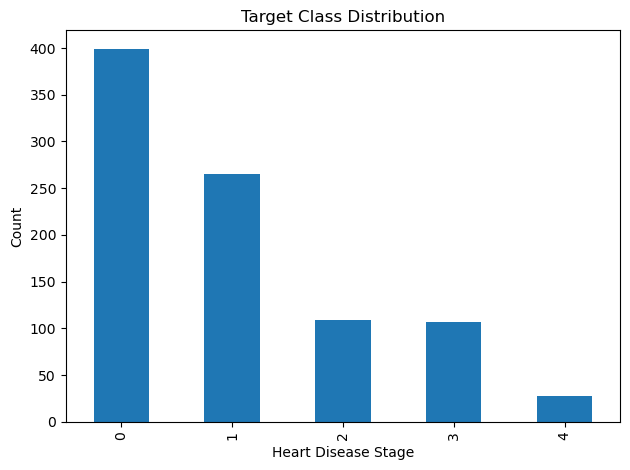

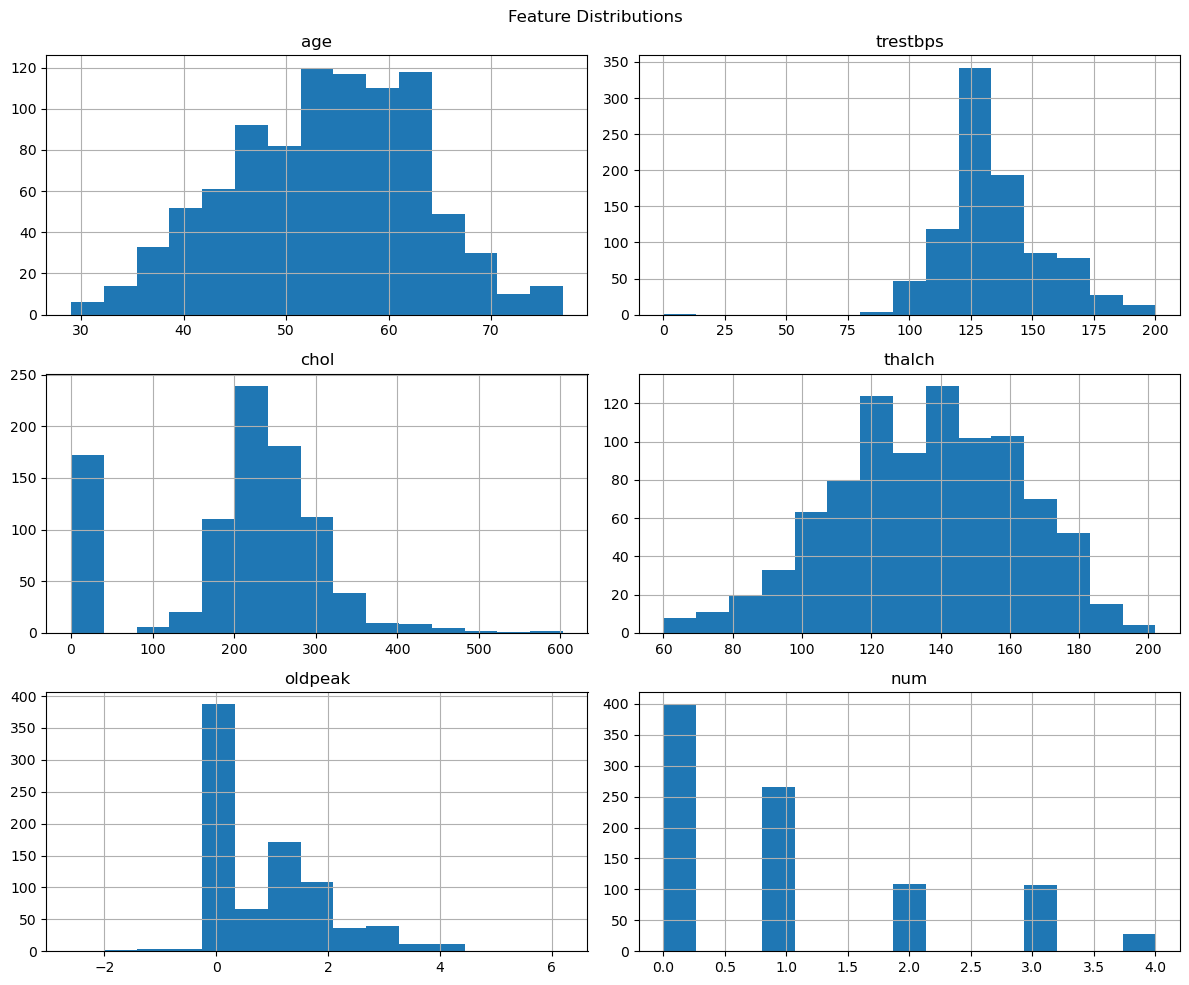

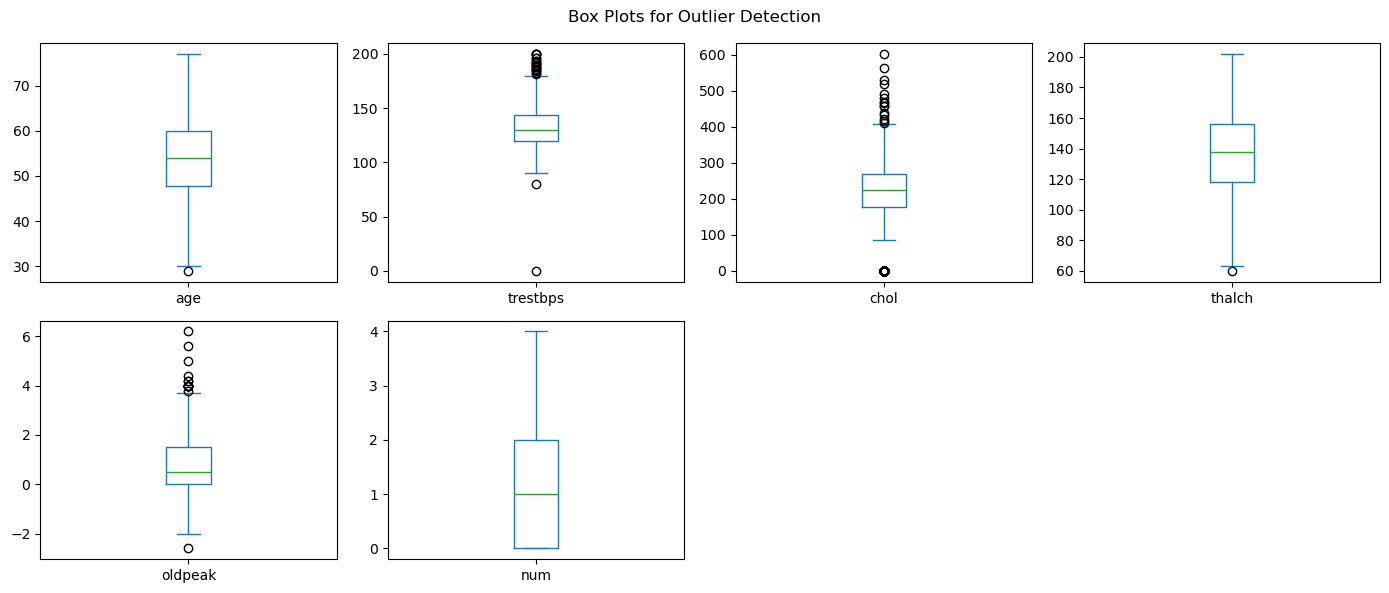

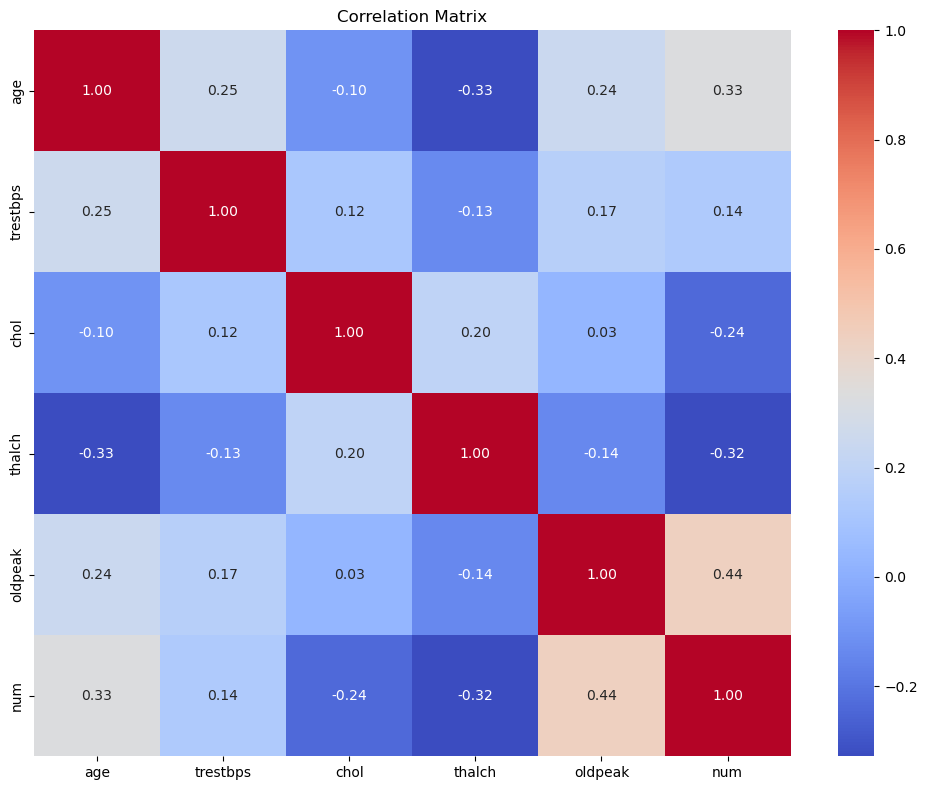

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Basic info
print(df.info())
print(df.describe())

# Missing values
print("\nMissing values:\n", df.isnull().sum())

# Target distribution
df['num'].value_counts().plot(kind='bar', title='Target Class Distribution')
plt.xlabel('Heart Disease Stage')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Histograms for numeric features
df.hist(figsize=(12, 10), bins=15)
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

# Box plots for outliers
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols].plot(kind='box', subplots=True, figsize=(14, 6), layout=(2, 4))
plt.suptitle('Box Plots for Outlier Detection')
plt.tight_layout()
plt.show()

# Correlation matrix (numeric only)
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [3]:
from sklearn.preprocessing import LabelEncoder

df_clean = df.copy()

# Handle missing values — fill numeric with median
for col in df_clean.select_dtypes(include='number').columns:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Encode categorical columns with Label Encoding
cat_cols = df_clean.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# Convert boolean columns (True/False) to int
bool_cols = df_clean.select_dtypes(include='bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

# Binarize target: 0 = no disease, 1 = disease (stages 1-4)
df_clean['target'] = (df_clean['num'] > 0).astype(int)
df_clean.drop(columns=['num'], inplace=True)

print(df_clean.head())
print("Target distribution:\n", df_clean['target'].value_counts())

   age  sex  cp  trestbps  chol  fbs  restecg  thalch  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0     150      1      2.3      0   
1   41    1   1       135   203    0        1     132      1      0.0      1   
2   57    1   0       140   192    0        1     148      1      0.4      1   
3   52    1   3       118   186    0        0     190      1      0.0      1   
4   57    1   0       110   201    0        1     126      3      1.5      1   

   thal  target  
0     0       0  
1     0       0  
2     0       0  
3     0       0  
4     0       0  
Target distribution:
 target
1    509
0    399
Name: count, dtype: int64


C:\Users\akshara\AppData\Local\Temp\ipykernel_14652\1633422641.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].median(), inplace=True)


Accuracy : 0.7252747252747253
Precision: 0.76
Recall   : 0.7450980392156863
F1-Score : 0.7524752475247525
ROC-AUC  : 0.7225490196078431

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.70      0.69        80
           1       0.76      0.75      0.75       102

    accuracy                           0.73       182
   macro avg       0.72      0.72      0.72       182
weighted avg       0.73      0.73      0.73       182



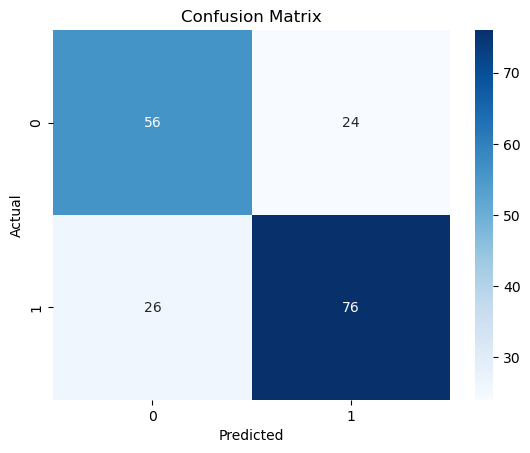

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix)

X = df_clean.drop(columns=['target'])
y = df_clean['target']

# 80-20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train the model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predict
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:, 1]

# Evaluation metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [5]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

# Retrain with best params
best_dt = grid_search.best_estimator_
y_pred_best = best_dt.predict(X_test)
y_prob_best = best_dt.predict_proba(X_test)[:, 1]

print("\n--- Tuned Model Performance ---")
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1-Score :", f1_score(y_test, y_pred_best))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_best))

Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 10}
Best CV Accuracy: 0.7768540387340577

--- Tuned Model Performance ---
Accuracy : 0.7087912087912088
Precision: 0.7578947368421053
Recall   : 0.7058823529411765
F1-Score : 0.7309644670050761
ROC-AUC  : 0.7568014705882353


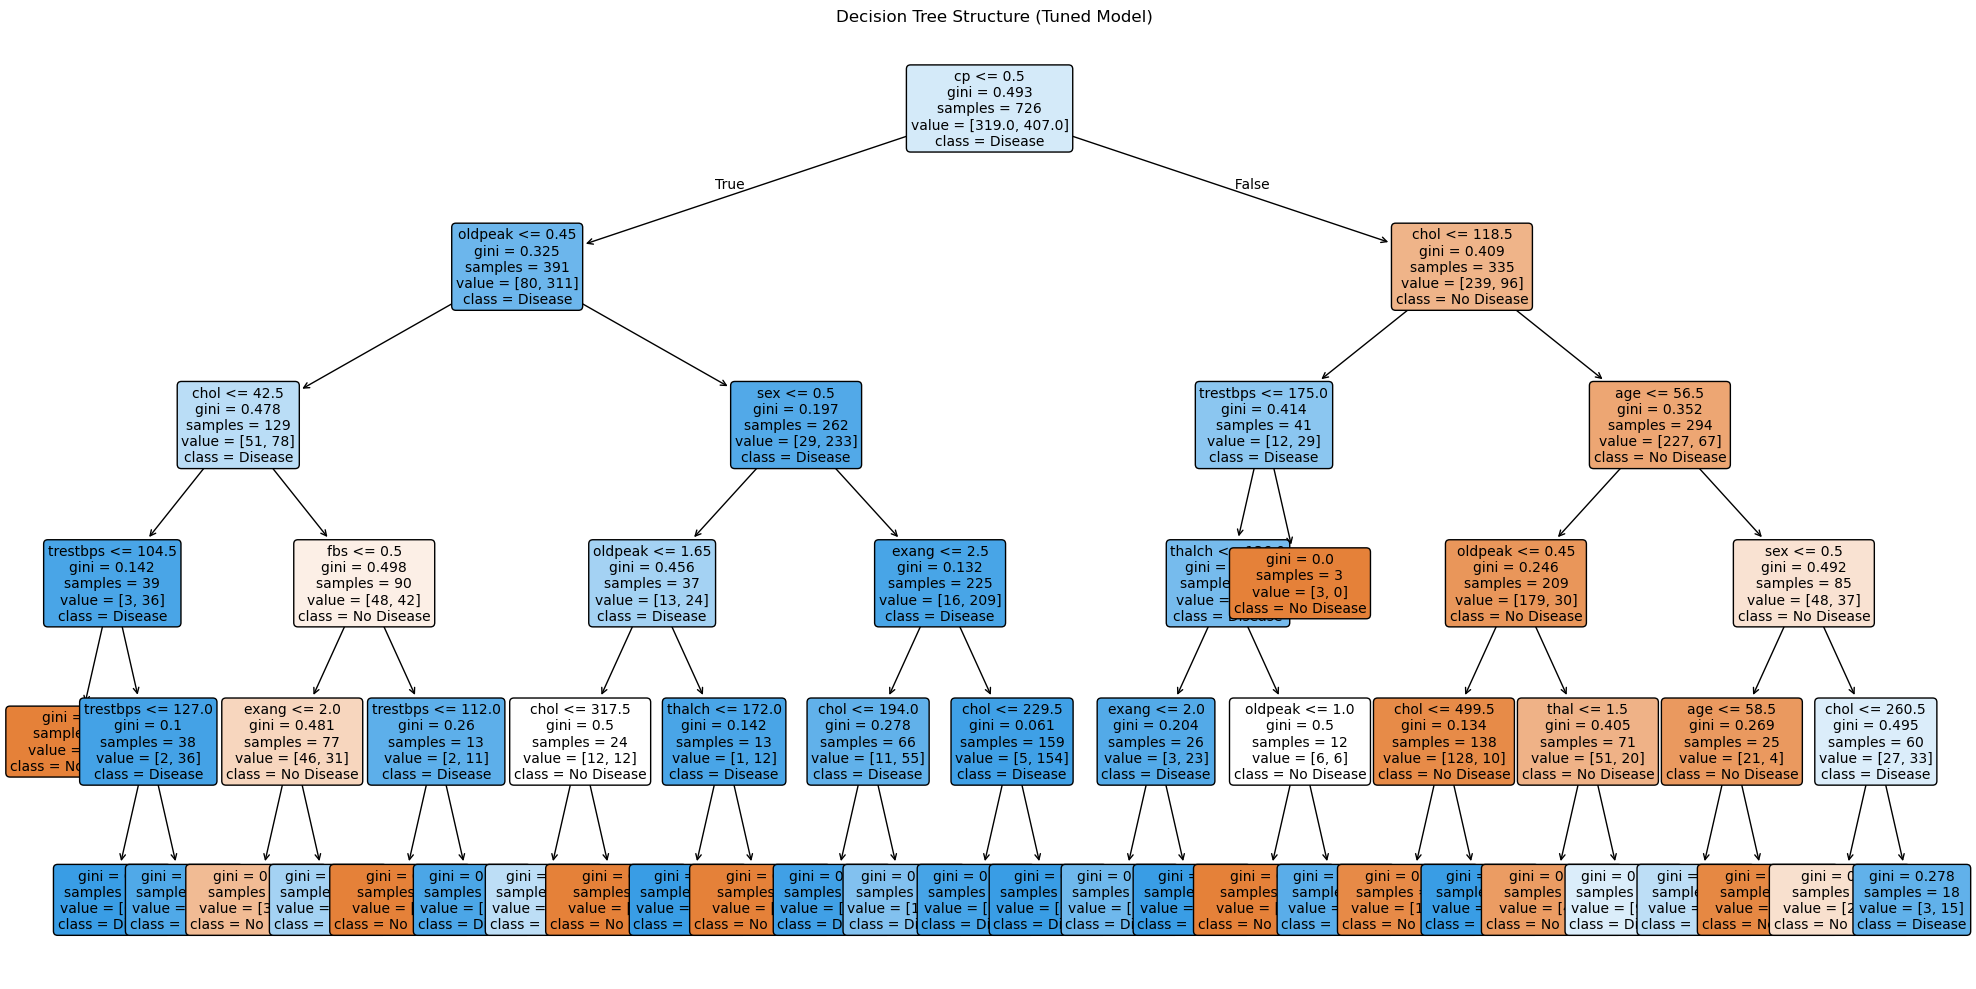

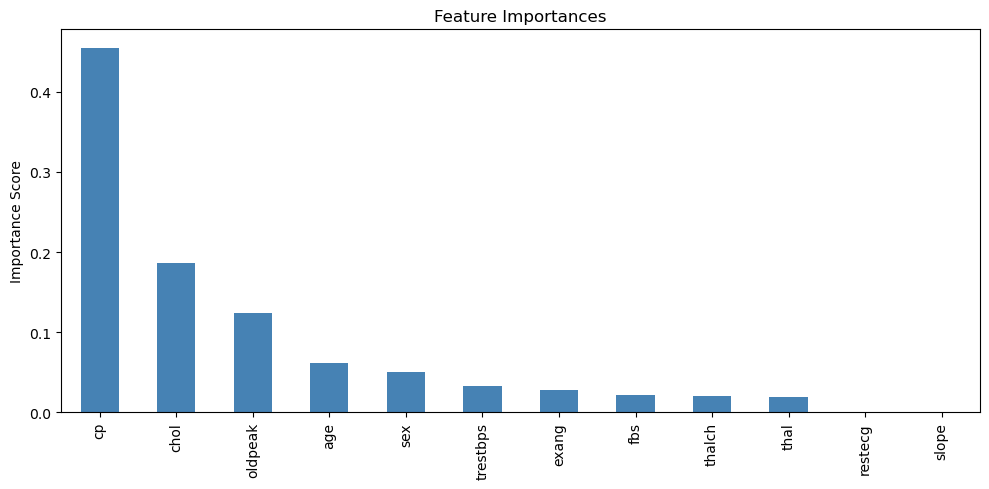

In [6]:
# Visualize Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(best_dt, feature_names=X.columns,
          class_names=['No Disease', 'Disease'],
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Structure (Tuned Model)')
plt.tight_layout()
plt.show()

# Feature Importance
importances = pd.Series(best_dt.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(10, 5), color='steelblue')
plt.title('Feature Importances')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()